## Model training

### 1.1 Import data and required packages

In [2]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import CSV data as pandas dataframe

In [3]:
df = pd.read_csv("data\StudentsPerformance.csv")

In [4]:
# Top 5 rows
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Preparing X and Y

In [5]:
X = df.drop(columns=['math score'])
Y = df['math score']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
# importing column transformer

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

num_features = X.select_dtypes(exclude="object").columns
catego_features = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer([
    ("one_hot", OneHotEncoder(), catego_features),
    ("Stand", StandardScaler(), num_features)
    ])

C:\Users\param\AppData\Local\Temp\ipykernel_16036\2101056076.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  catego_features = X.select_dtypes(include="object").columns


Train_test_split

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((800, 7), (200, 7))

Apply the Preprocessor on X

In [9]:
X_train=preprocessor.fit_transform(X_train)
X_test=preprocessor.transform(X_test)

X_train.shape, X_test.shape

((800, 19), (200, 19))

Evaluate Function

In [10]:
def evaluate_function(true,predicted):
    mae= mean_absolute_error(true,predicted)
    rmse= root_mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    return mae, rmse, r2

Train and Evaluate All Models

In [11]:
models = {
    "Linear Regression"      : LinearRegression(),
    "Lasso"                 : Lasso(),
    "Ridge"                 : Ridge(),
    "KNeighborsRegressor"  : KNeighborsRegressor(),
    "DecisionTreeRegressor" : DecisionTreeRegressor(),
    "AdaBoostRegressor"     : AdaBoostRegressor(),
    "XGboost"               : XGBRegressor(),
    "Catboost"              : CatBoostRegressor(),
    "RandomForestRegressor" : RandomForestRegressor()
}

models_list = []
r2_list = []

for name, model in models.items():
    model.fit(X_train, Y_train)

    Y_train_pred = model.predict(X_train)
    Y_test_pred = model.predict(X_test)

    train_mae, train_rmse, train_r2 = evaluate_function(Y_train, Y_train_pred)
    test_mae, test_rmse, test_r2 = evaluate_function(Y_test, Y_test_pred)

    models_list.append(name)

    print(name)
    print(f"train -> mae = {train_mae:.4f} | rmse = {train_rmse:.4f} | r2 = {train_r2:.4f}")
    print(f"test ->  mae = {test_mae:.4f} | rmse = {test_rmse:.4f} | r2 = {test_r2:.4f}")
    print("="*50)

    r2_list.append(test_r2)


Linear Regression
train -> mae = 4.2667 | rmse = 5.3231 | r2 = 0.8743
test ->  mae = 4.2148 | rmse = 5.3940 | r2 = 0.8804
Lasso
train -> mae = 5.2053 | rmse = 6.5925 | r2 = 0.8072
test ->  mae = 5.1557 | rmse = 6.5173 | r2 = 0.8254
Ridge
train -> mae = 4.2650 | rmse = 5.3233 | r2 = 0.8743
test ->  mae = 4.2111 | rmse = 5.3904 | r2 = 0.8806
KNeighborsRegressor
train -> mae = 4.5042 | rmse = 5.6974 | r2 = 0.8560
test ->  mae = 5.5880 | rmse = 7.2172 | r2 = 0.7859
DecisionTreeRegressor
train -> mae = 0.0187 | rmse = 0.2795 | r2 = 0.9997
test ->  mae = 6.3500 | rmse = 7.9265 | r2 = 0.7418
AdaBoostRegressor
train -> mae = 4.8048 | rmse = 5.8614 | r2 = 0.8476
test ->  mae = 4.6928 | rmse = 5.9752 | r2 = 0.8533
XGboost
train -> mae = 0.6875 | rmse = 1.0073 | r2 = 0.9955
test ->  mae = 5.0577 | rmse = 6.4733 | r2 = 0.8278
Learning rate set to 0.039525
0:	learn: 14.5987177	total: 108ms	remaining: 1m 48s
1:	learn: 14.2251886	total: 111ms	remaining: 55.4s
2:	learn: 13.8866124	total: 114ms	remaini

Results Table + Visualisations

In [12]:
results_df = pd.DataFrame({
    "Model Name" : models_list,
    "R2 score"   : r2_list
}).sort_values(by="R2 score", ascending=False).reset_index(drop=True)

results_df

,Model Name,R2 score
0,Ridge,0.880592
1,Linear Regression,0.880433
2,AdaBoostRegressor,0.853280
3,Catboost,0.851831
4,RandomForestRegressor,0.851271
5,XGboost,0.827797
6,Lasso,0.825446
7,KNeighborsRegressor,0.785944
8,DecisionTreeRegressor,0.741800


Re-train Linear Regression and Check Accuracy

In [13]:
lin_model = LinearRegression(fit_intercept=True)
lin_model.fit(X_train,Y_train)
y_pred = lin_model.predict(X_test)

score = r2_score(Y_test, y_pred)*100
print(f"Accuracy of the model is : {score:.2f}%")

Accuracy of the model is : 88.04%


Scatter Plot (Actual vs Predicted)

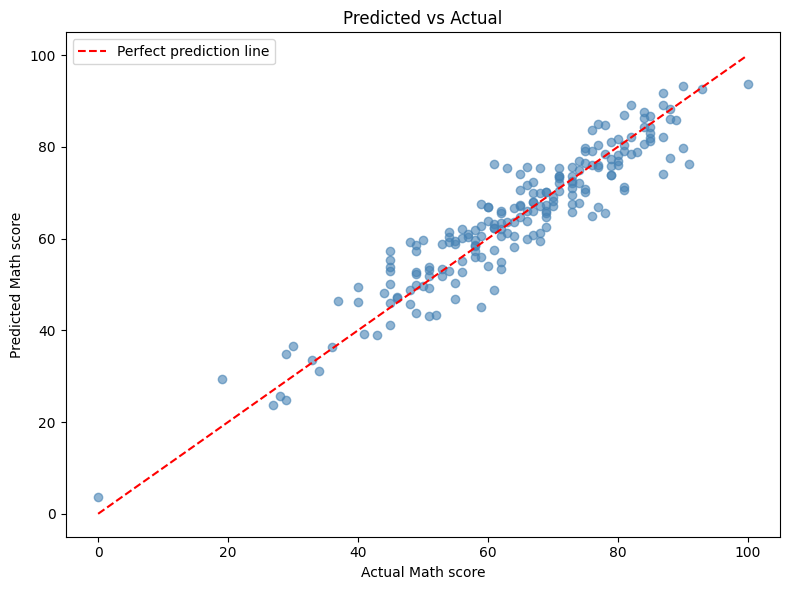

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(Y_test, y_pred, alpha=0.6, color="steelblue")
plt.xlabel("Actual Math score")
plt.ylabel("Predicted Math score")
plt.title("Predicted vs Actual")

plt.plot([Y_test.min(), Y_test.max()],[Y_test.min(), Y_test.max()], color='red', linestyle="--", label="Perfect prediction line")

plt.legend()
plt.tight_layout()
plt.show()